In [2]:
import sys
sys.path.append("..")

import json
import numpy as np
import torch
import matplotlib.pyplot as plt

from pathlib import Path

from src.anomaly.sequence_dataset import create_sequences
from src.anomaly.lstm_autoencoder import LSTMAutoencoder

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [4]:
model = LSTMAutoencoder(
    n_features=3,
    hidden_size=64,
    latent_size=32
).to(device)

model.load_state_dict(
    torch.load(
        "../src/models/lstm_autoencoder.pt",
        map_location=device
    )
)

model.eval()

print("Model loaded.")

Model loaded.


In [5]:
with open(
    "../src/models/threshold.json",
    "r"
) as f:

    threshold = json.load(f)["threshold"]

print("Threshold:", threshold)

Threshold: 1.0785417556762695


In [6]:
f1_attack = np.load("../src/models/gps_imu_f1.npy")
f2_attack = np.load("../src/models/gps_imu_f2.npy")
gmis_attack = np.load("../src/models/gps_imu_gmis.npy")

In [7]:
'''attack feature matrix'''
attack_min_len = min(
    len(f1_attack),
    len(f2_attack),
    len(gmis_attack)
)

X_attack = np.column_stack([
    f1_attack[:attack_min_len],
    f2_attack[:attack_min_len],
    gmis_attack[:attack_min_len]
])

X_attack = X_attack[
    ~np.isnan(X_attack).any(axis=1)
]

print(X_attack.shape)

(437, 3)


In [8]:
'''sequences'''
SEQ_LEN = 200

X_attack_seq = create_sequences(
    X_attack,
    seq_len=SEQ_LEN
)

print(X_attack_seq.shape)

(238, 200, 3)


In [9]:
'''converting to tensor'''
X_attack_tensor = torch.tensor(
    X_attack_seq,
    dtype=torch.float32
).to(device)

In [10]:
'''reconstruction error'''
model.eval()

with torch.no_grad():

    reconstructed = model(
        X_attack_tensor
    )

    attack_errors = torch.mean(
        (X_attack_tensor - reconstructed) ** 2,
        dim=(1, 2)
    ).cpu().numpy()

print("Attack Mean Error:", attack_errors.mean())
print("Attack Std Error :", attack_errors.std())
print("Attack Max Error :", attack_errors.max())

Attack Mean Error: 16.645147
Attack Std Error : 2.656481
Attack Max Error : 20.070318


In [11]:
'''detection rate'''
detections = np.sum(
    attack_errors > threshold
)

print("Detections:", detections)
print("Total:", len(attack_errors))

print(
    f"Detection Rate: {100*detections/len(attack_errors):.2f}%"
)

Detections: 238
Total: 238
Detection Rate: 100.00%


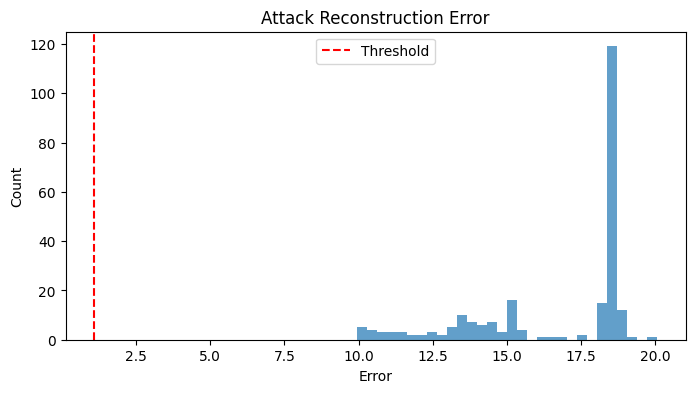

In [12]:
'''visualization rate'''
plt.figure(figsize=(8,4))

plt.hist(
    attack_errors,
    bins=30,
    alpha=0.7
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    label="Threshold"
)

plt.legend()
plt.title("Attack Reconstruction Error")

plt.xlabel("Error")
plt.ylabel("Count")

plt.show()

In [13]:
print("Threshold:", threshold)
print("Attack Mean:", attack_errors.mean())
print("Attack Min:", attack_errors.min())

Threshold: 1.0785417556762695
Attack Mean: 16.645147
Attack Min: 9.946823


cam + imu

In [14]:
f1_attack = np.load("../src/models/camera_imu_f1.npy")
f2_attack = np.load("../src/models/camera_imu_f2.npy")
gmis_attack = np.load("../src/models/camera_imu_gmis.npy")

In [15]:
'''attack feature matrix'''
attack_min_len = min(
    len(f1_attack),
    len(f2_attack),
    len(gmis_attack)
)

X_attack = np.column_stack([
    f1_attack[:attack_min_len],
    f2_attack[:attack_min_len],
    gmis_attack[:attack_min_len]
])

X_attack = X_attack[
    ~np.isnan(X_attack).any(axis=1)
]

print(X_attack.shape)

(437, 3)


In [16]:
'''sequences'''
SEQ_LEN = 200

X_attack_seq = create_sequences(
    X_attack,
    seq_len=SEQ_LEN
)

print(X_attack_seq.shape)

(238, 200, 3)


In [17]:
'''converting to tensor'''
X_attack_tensor = torch.tensor(
    X_attack_seq,
    dtype=torch.float32
).to(device)

In [18]:
'''reconstruction error'''
model.eval()

with torch.no_grad():

    reconstructed = model(
        X_attack_tensor
    )

    attack_errors = torch.mean(
        (X_attack_tensor - reconstructed) ** 2,
        dim=(1, 2)
    ).cpu().numpy()

print("Attack Mean Error:", attack_errors.mean())
print("Attack Std Error :", attack_errors.std())
print("Attack Max Error :", attack_errors.max())

Attack Mean Error: 10.8474
Attack Std Error : 1.2932087
Attack Max Error : 11.716884


In [19]:
'''detection rate'''
detections = np.sum(
    attack_errors > threshold
)

print("Detections:", detections)
print("Total:", len(attack_errors))

print(
    f"Detection Rate: {100*detections/len(attack_errors):.2f}%"
)

Detections: 238
Total: 238
Detection Rate: 100.00%


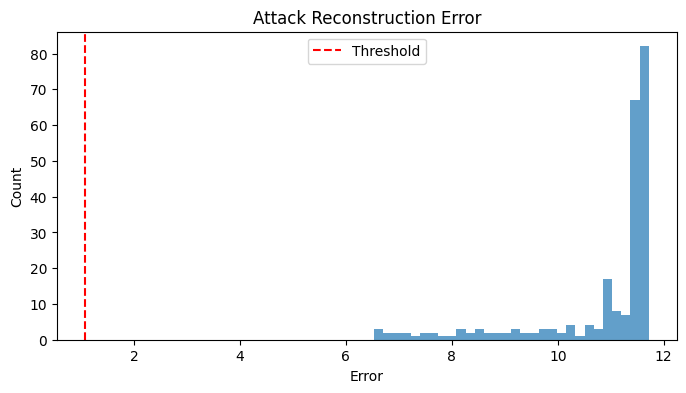

In [20]:
'''visualization rate'''
plt.figure(figsize=(8,4))

plt.hist(
    attack_errors,
    bins=30,
    alpha=0.7
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    label="Threshold"
)

plt.legend()
plt.title("Attack Reconstruction Error")

plt.xlabel("Error")
plt.ylabel("Count")

plt.show()

In [21]:
print("Threshold:", threshold)
print("Attack Mean:", attack_errors.mean())
print("Attack Min:", attack_errors.min())

Threshold: 1.0785417556762695
Attack Mean: 10.8474
Attack Min: 6.5302815


gps + lidar

In [22]:
f1_attack = np.load("../src/models/gps_lidar_f1.npy")
f2_attack = np.load("../src/models/gps_lidar_f2.npy")
gmis_attack = np.load("../src/models/gps_imu_gmis.npy")

In [23]:
'''attack feature matrix'''
attack_min_len = min(
    len(f1_attack),
    len(f2_attack),
    len(gmis_attack)
)

X_attack = np.column_stack([
    f1_attack[:attack_min_len],
    f2_attack[:attack_min_len],
    gmis_attack[:attack_min_len]
])

X_attack = X_attack[
    ~np.isnan(X_attack).any(axis=1)
]

print(X_attack.shape)

(437, 3)


In [24]:
'''sequences'''
SEQ_LEN = 200

X_attack_seq = create_sequences(
    X_attack,
    seq_len=SEQ_LEN
)

print(X_attack_seq.shape)

(238, 200, 3)


In [25]:
'''converting to tensor'''
X_attack_tensor = torch.tensor(
    X_attack_seq,
    dtype=torch.float32
).to(device)

In [26]:
'''reconstruction error'''
model.eval()

with torch.no_grad():

    reconstructed = model(
        X_attack_tensor
    )

    attack_errors = torch.mean(
        (X_attack_tensor - reconstructed) ** 2,
        dim=(1, 2)
    ).cpu().numpy()

print("Attack Mean Error:", attack_errors.mean())
print("Attack Std Error :", attack_errors.std())
print("Attack Max Error :", attack_errors.max())

Attack Mean Error: 4.722926
Attack Std Error : 1.2480705
Attack Max Error : 6.3273277


In [27]:
'''detection rate'''
detections = np.sum(
    attack_errors > threshold
)

print("Detections:", detections)
print("Total:", len(attack_errors))

print(
    f"Detection Rate: {100*detections/len(attack_errors):.2f}%"
)

Detections: 238
Total: 238
Detection Rate: 100.00%


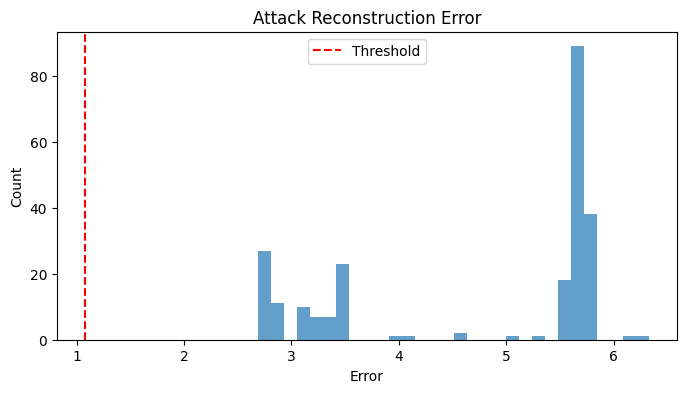

In [28]:
'''visualization rate'''
plt.figure(figsize=(8,4))

plt.hist(
    attack_errors,
    bins=30,
    alpha=0.7
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    label="Threshold"
)

plt.legend()
plt.title("Attack Reconstruction Error")

plt.xlabel("Error")
plt.ylabel("Count")

plt.show()

In [29]:
print("Threshold:", threshold)
print("Attack Mean:", attack_errors.mean())
print("Attack Min:", attack_errors.min())

Threshold: 1.0785417556762695
Attack Mean: 4.722926
Attack Min: 2.6925442
